In [ ]:
import polars as pl
import os
import json
from pathlib import Path

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]  # Fast_Data_Discovery
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

# Dataset name mapping (internal name -> paper name from datasets.tex)
DATASET_NAMES = {
    'elections': 'Elections',
    'realestate': 'Real Estate',
    'energy': 'Energy',
    'fire': 'Fire Incidents',
    'imdb': 'IMDB',
    'jobs': 'Jobs',
    'pageviews': 'Page Views',
    'vgsales': 'VG Sales',
    'arrests': 'Arrest Records',
    'foodfacts': 'Food Facts',
    'hospital': 'Hospital',
    'trees': 'Street Trees',
}

exp_path = NOTEBOOK_DIR / 'logs'
exp_dir = os.listdir(exp_path)
rows = []
for exp in exp_dir:
    if not os.path.isdir(exp_path / exp):
        continue
    comb_log = exp_path / exp / f'{exp}.log'
    with open(comb_log) as f:
        lines = f.readlines()
    for i in range(len(lines)):
        lines[i] = json.loads(lines[i])
    selection_runtime = None
    fitted_features = None
    aug_plan_len = None
    for entry in lines:
        if entry.get('message') == 'Selection':
            selection_runtime = entry['runtime']
        if entry.get('message') == 'Pruning':
            fitted_features = entry['fitted_features']
        if entry.get('message') == 'Augmentation':
            aug_plan = entry.get('augmentation_plan', [])
            aug_plan_len = len(aug_plan) if aug_plan else 0
    if selection_runtime is not None:
        rows.append({
            'experiment': exp,
            'runtime': selection_runtime,
            'fitted_features': fitted_features,
            'aug_plan_len': aug_plan_len,
        })
runtime_df = pl.from_dicts(rows)
runtime_df = runtime_df.with_columns(
    pl.col('experiment').str.split('_').list.to_struct(upper_bound=3, fields=['lake', 'table', 'model']).struct.unnest()
)

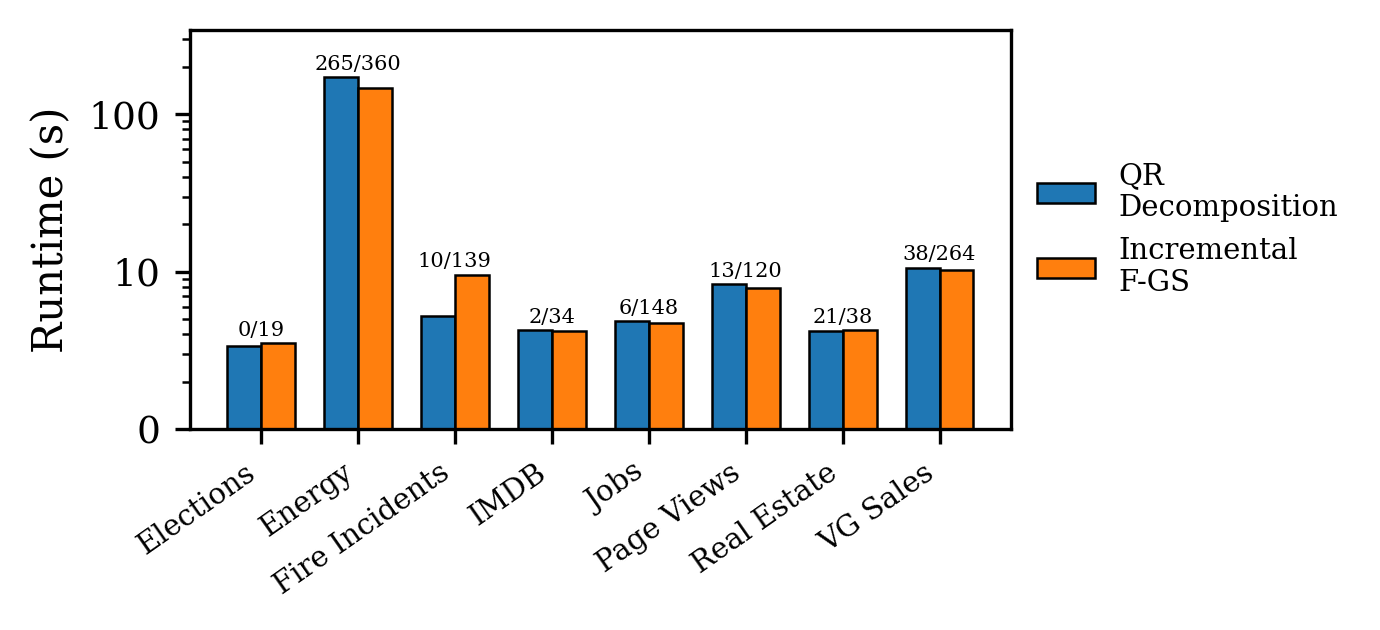

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

# Keep only datasets that have both models
both = (
    runtime_df
    .group_by(['lake', 'table']).agg(pl.col('model').n_unique().alias('n_models'))
    .filter(pl.col('n_models') == 2)
)
data = runtime_df.join(both.select('lake', 'table'), on=['lake', 'table'])

# Pivot runtime, fitted_features, aug_plan_len
pivot_rt = (
    data.pivot(on='model', index=['lake', 'table'], values='runtime')
    .with_columns(pl.col('table').replace(DATASET_NAMES).alias('dataset')).sort('dataset')
)
pivot_ff = (
    data.pivot(on='model', index=['lake', 'table'], values='fitted_features')
    .with_columns(pl.col('table').replace(DATASET_NAMES).alias('dataset')).sort('dataset')
)
pivot_ap = (
    data.pivot(on='model', index=['lake', 'table'], values='aug_plan_len')
    .with_columns(pl.col('table').replace(DATASET_NAMES).alias('dataset')).sort('dataset')
)

datasets = pivot_rt['dataset'].to_list()
incremental = pivot_rt['IncrementalRegressionFGS'].to_list()
full = pivot_rt['RegressionQR'].to_list()
ff_full = pivot_ff['RegressionQR'].to_list()
ff_inc = pivot_ff['IncrementalRegressionFGS'].to_list()
ap_full = pivot_ap['RegressionQR'].to_list()
ap_inc = pivot_ap['IncrementalRegressionFGS'].to_list()

x = np.arange(len(datasets))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(4.5, 2.0))
bars_full = ax.bar(x - bar_w/2, full, bar_w,
                   label='QR\nDecomposition', color='#1f77b4',
                   edgecolor='black', linewidth=0.6)
bars_inc = ax.bar(x + bar_w/2, incremental, bar_w,
                  label='Incremental\nF-GS', color='#ff7f0e',
                  edgecolor='black', linewidth=0.6)

# Annotate aug_plan_len/fitted_features on the taller bar only
for i in range(len(datasets)):
    if full[i] >= incremental[i]:
        bar = bars_full[i]
        a, f = ap_full[i], ff_full[i]
    else:
        bar = bars_inc[i]
        a, f = ap_inc[i], ff_inc[i]
    cx = x[i]
    ax.text(cx, bar.get_height() * 1.05,
            f'{a}/{f}', ha='center', va='bottom', fontsize=5)

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=35, ha='right', fontsize=7)
ax.set_ylabel('Runtime (s)')
ax.set_yscale('log')
ax.set_yticks([1, 10, 100])
ax.set_yticklabels(['0', '10', '100'])
ax.set_ylim(bottom=1, top=max(max(full), max(incremental)) * 2)
ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout(pad=0.3)
plt.savefig(PAPER_ROOT / 'figures' / 'full_incremental_ablation.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()

In [ ]:
# --- Generate TikZ ---
# Compute label for each dataset (only on taller bar)
annotations = []
for i in range(len(datasets)):
    if full[i] >= incremental[i]:
        h = full[i]
        a, f = ap_full[i], ff_full[i]
    else:
        h = incremental[i]
        a, f = ap_inc[i], ff_inc[i]
    annotations.append((i, h, f'{a}/{f}'))

tikz = [
    r"\definecolor{barblue}{RGB}{31,119,180}",
    r"\definecolor{baronge}{RGB}{255,127,14}",
    r"\begin{tikzpicture}",
    r"\begin{axis}[",
    r"  width=\linewidth,",
    r"  height=1.2in,",
    r"  ybar,",
    f"  bar width={bar_w*0.8:.2f}cm,",
    r"  ylabel={Runtime (s)},",
    r"  ymode=log,",
    r"  ytick={1,10,100},",
    r"  yticklabels={0,10,100},",
    r"  ymin=1,",
    f"  xtick={{{','.join(str(i) for i in range(len(datasets)))}}},",
    f"  xticklabels={{{','.join(datasets)}}},",
    r"  x tick label style={rotate=35, anchor=east, font=\small},",
    r"  y tick label style={font=\small},",
    r"  label style={font=\small},",
    r"  legend style={font=\small, at={(0.98,0.95)}, anchor=north east, draw=black, fill=white, fill opacity=0.85, text opacity=1},",
    f"  xmin=-0.8,",
    f"  xmax={len(datasets)-1+0.8},",
    r"  enlarge x limits=false,",
    r"  axis lines=left,",
    r"  clip=false,",
    r"]",
]

# Full bars
coords_full = " ".join(f"({i},{v:.1f})" for i, v in enumerate(full))
tikz.append(r"\addplot[fill=barblue, draw=black, line width=0.6pt]")
tikz.append(f"  coordinates {{{coords_full}}};")
tikz.append(r"\addlegendentry{QR Decomposition}")

# Incremental bars
coords_inc = " ".join(f"({i},{v:.1f})" for i, v in enumerate(incremental))
tikz.append(r"\addplot[fill=baronge, draw=black, line width=0.6pt]")
tikz.append(f"  coordinates {{{coords_inc}}};")
tikz.append(r"\addlegendentry{Incremental F-GS}")

# Add annotation nodes centered above the taller bar
for xi, h, label in annotations:
    tikz.append(f"\\node[font=\\footnotesize, above] at (axis cs:{xi},{h:.1f}) {{{label}}};")

tikz.append(r"\end{axis}")
tikz.append(r"\end{tikzpicture}")

tikz_code = "\n".join(tikz)
out_path = PAPER_ROOT / 'figures' / 'full_incremental_ablation.tex'
out_path.write_text(tikz_code)
print(f"TikZ written to {out_path}")

TikZ written to /home/fedor/Matryoshka/figures/full_incremental_ablation.tex
